In [ ]:
import pandas as pd
from collections import defaultdict

d = pd.read_table('df_new_all_lemma.tsv', sep='\t', on_bad_lines='skip')

df = d[['Smell_Word', 'year']].copy()
df['year'] = pd.to_numeric(df['year'], errors='coerce')

def get_century(year):
    return int(year) // 100 + 1 if pd.notnull(year) else None

df = df.dropna(subset=['Smell_Word', 'year'])

df['century'] = df['year'].apply(get_century)

word_freq_per_century = defaultdict(lambda: defaultdict(int))

for _, row in df.iterrows():
    century = row['century']
    words = str(row['Smell_Word']).lower().split('|')  # Split on pipes
    for word in words:
        word = word.strip()
        if century and word:
            word_freq_per_century[century][word] += 1

total_freq_per_century = {
    century: sum(freqs.values())
    for century, freqs in word_freq_per_century.items()
}

with open('smell_freq_norm_final.tsv', 'w') as f:
    f.write("century\tword\tfreq_normal\n")
    for century in sorted(word_freq_per_century):
        total = total_freq_per_century[century]
        for word, count in sorted(word_freq_per_century[century].items(), key=lambda x: x[1], reverse=True):
            freq_normal = count / total
            f.write(f"{century}\t{word}\t{freq_normal:.8f}\n")

/var/folders/j8/2fw1pn3n4zb1y5l8gt8s56dc0000gn/T/ipykernel_12071/4276438541.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_century = df_century[df['word'].apply(lambda x: len(str(x)) >= 3)].head(num_top_words)


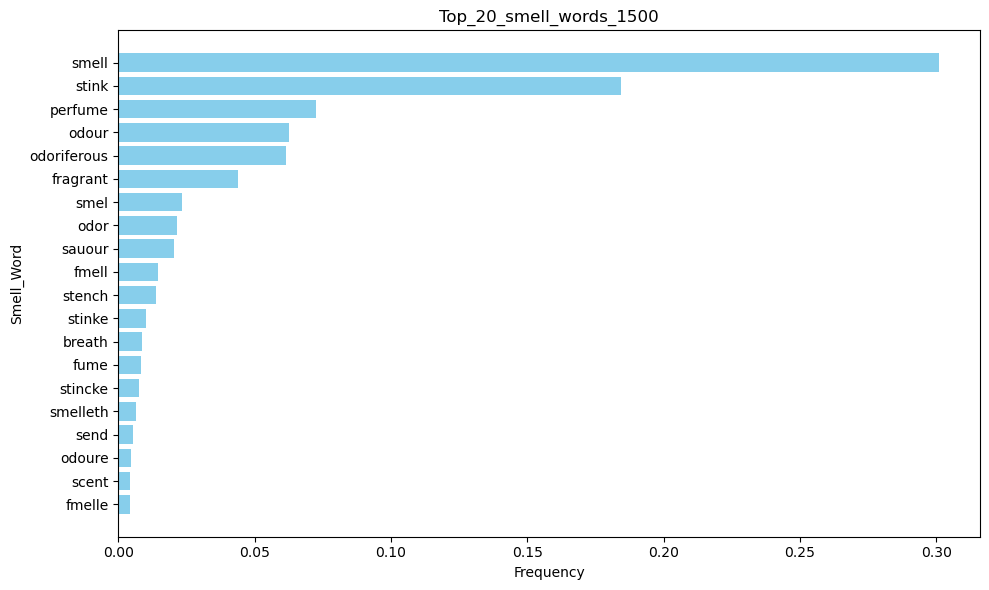

/var/folders/j8/2fw1pn3n4zb1y5l8gt8s56dc0000gn/T/ipykernel_12071/4276438541.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_century = df_century[df['word'].apply(lambda x: len(str(x)) >= 3)].head(num_top_words)


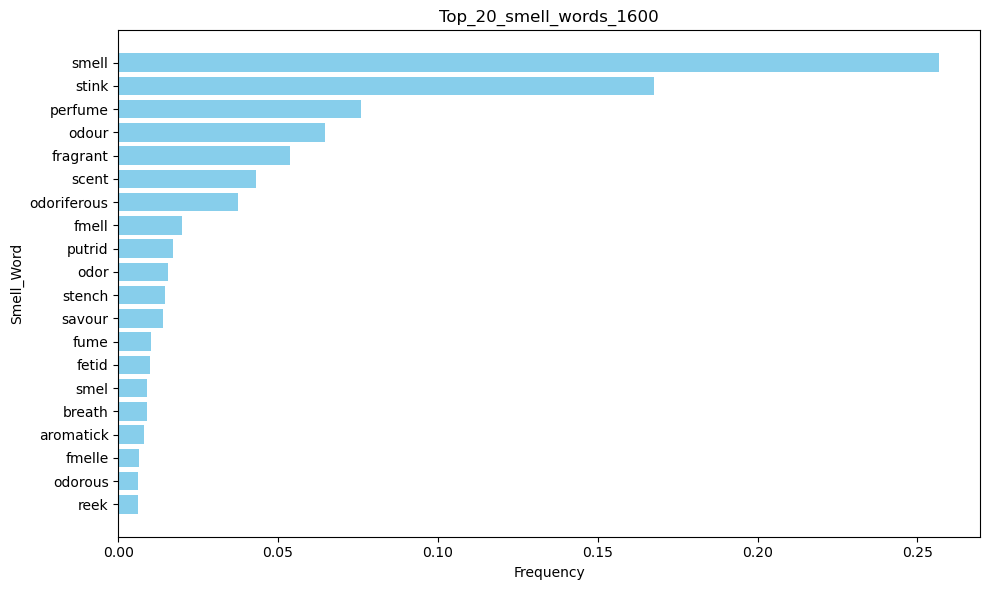

/var/folders/j8/2fw1pn3n4zb1y5l8gt8s56dc0000gn/T/ipykernel_12071/4276438541.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_century = df_century[df['word'].apply(lambda x: len(str(x)) >= 3)].head(num_top_words)


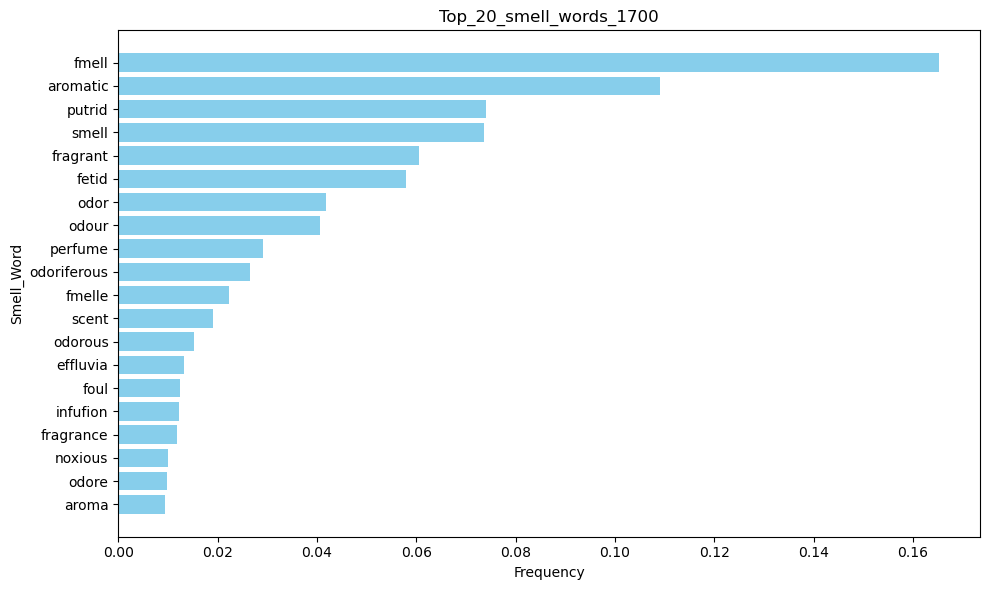

/var/folders/j8/2fw1pn3n4zb1y5l8gt8s56dc0000gn/T/ipykernel_12071/4276438541.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_century = df_century[df['word'].apply(lambda x: len(str(x)) >= 3)].head(num_top_words)


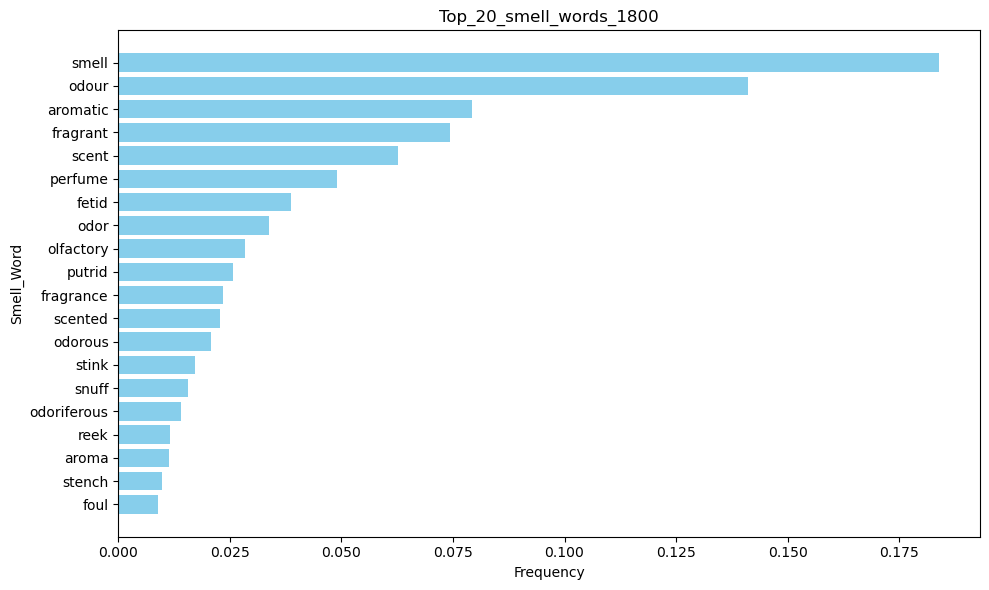

/var/folders/j8/2fw1pn3n4zb1y5l8gt8s56dc0000gn/T/ipykernel_12071/4276438541.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_century = df_century[df['word'].apply(lambda x: len(str(x)) >= 3)].head(num_top_words)


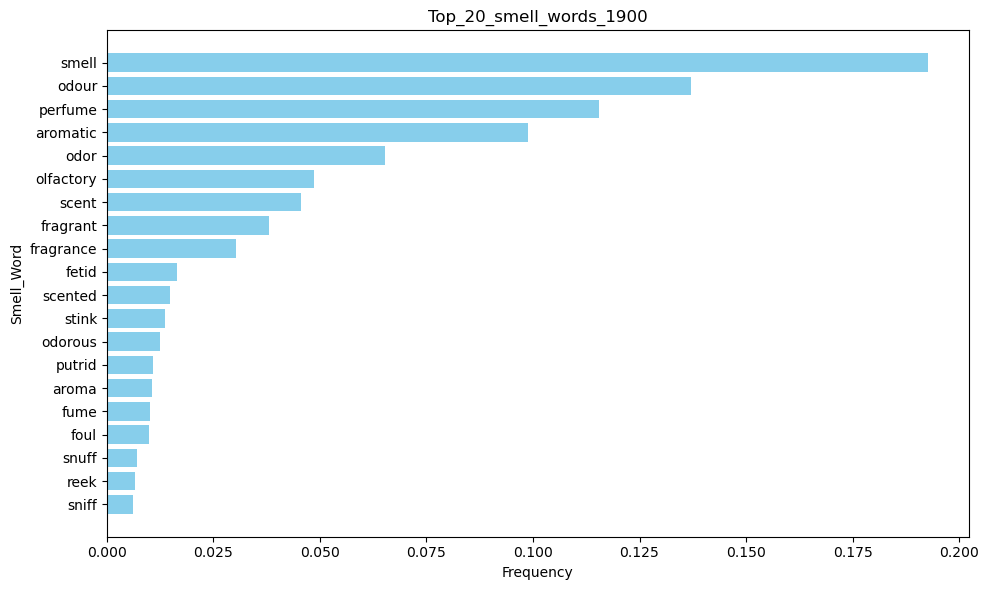

In [11]:
import matplotlib.pyplot as plt

num_top_words = 20
centuries = range(16, 21)

df = pd.read_csv('smell_freq_norm_final_clean.tsv', sep='\t')

for century in centuries:
    df_century = df[(df['century'] == century)]
    df_century = df_century[df['word'].apply(lambda x: len(str(x)) >= 3)].head(num_top_words)
    
    plt.figure(figsize=(10, 6))
    plt.barh(df_century['word'], df_century['freq_normal'], color='skyblue')
    plt.xlabel('Frequency')
    plt.ylabel('Smell_Word')
    plt.title(f'Top_{num_top_words}_smell_words_{century-1}00')
    plt.gca().invert_yaxis() 
    plt.tight_layout()
    plt.show()